# Notebook 6 — Final Analysis and Interpretation

## Lightweight ECG Signal Classification Using Machine Learning and Deep Learning Models

### Purpose

This notebook provides the final analysis and scientific interpretation of the experimental results obtained in Notebook 5.

Notebook 5 is treated as a **frozen experimental record**. Its final model selection, validation results, efficiency measurements, and held-out test results are not modified or re-evaluated for the purpose of model selection.

The final selected model is the **Quantised CNN**.

The purpose of Notebook 6 is therefore not to train or optimise another model, but to determine what the completed experiments mean in terms of:

- predictive performance;
- pruning behaviour;
- quantisation efficiency;
- model-size reduction;
- prediction-time reduction;
- performance–efficiency trade-offs;
- held-out test performance;
- participant-level generalisation, where the required frozen predictions are available;
- variability across held-out participants;
- methodological limitations; and
- implications for the dissertation research question.

### Experimental controls

The following principles are maintained throughout this notebook:

1. Notebook 5 is treated as the source of truth for all frozen experimental results.
2. No model is retrained.
3. No pruning experiment is repeated.
4. No quantisation experiment is repeated.
5. No hyperparameters are tuned.
6. No additional model selection is performed.
7. The held-out test set is not used to make modelling decisions.
8. Validation results and held-out test results are reported separately.
9. Participant-level analysis is performed only when the required participant identifiers and corresponding frozen predictions are available.
10. No clinical, hardware-deployment, or real-world wearable-performance claims are made beyond what the experiments directly demonstrate.

### Analysis principle

The objective is to present the experimental findings honestly rather than to maximise the apparent performance of the final model.

All conclusions in this notebook should therefore distinguish between:

- **predictive performance**, and
- **computational efficiency**,

while explicitly considering the limited number of held-out participants.

In [ ]:
# Cell 2
# ============================================================
# NOTEBOOK 6 — LOAD FROZEN NOTEBOOK 5 RESULTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Frozen Notebook 5 final results
# Source of truth: completed and frozen Notebook 5
# ------------------------------------------------------------

FROZEN_RESULTS = {
    "selected_model": "Quantised CNN",

    # --------------------------------------------------------
    # Validation performance
    # --------------------------------------------------------
    "baseline_f1": 0.793242,
    "baseline_roc_auc": 0.746448,

    "pruning_20_f1": 0.816092,
    "pruning_20_roc_auc": 0.745819,

    "pruning_40_f1": 0.827908,
    "pruning_40_roc_auc": 0.764577,

    "pruning_60_f1": 0.840459,
    "pruning_60_roc_auc": 0.777945,
    "pruning_60_recall": 0.799777,
    "pruning_60_actual_sparsity": 0.5873,

    "pruning_80_f1": 0.836807,
    "pruning_80_roc_auc": 0.780374,

    "quantised_f1": 0.788787,
    "quantised_roc_auc": 0.744670,
    "quantised_recall": 0.697309,

    # --------------------------------------------------------
    # Paired validation efficiency measurements
    # --------------------------------------------------------
    "baseline_prediction_time": 51.093595,
    "quantised_prediction_time": 27.691437,

    "model_size_reduction_percent": 34.10,
    "prediction_time_reduction_percent": 45.80,
    "inference_speedup": 1.845,

    # --------------------------------------------------------
    # Final held-out test evaluation
    # --------------------------------------------------------
    "test_accuracy": 0.656852,
    "test_precision": 0.899348,
    "test_recall": 0.625804,
    "test_f1": 0.738045,
    "test_roc_auc": 0.773637,

    "test_samples": 65581,
    "test_participants": 5,
    "test_prediction_time": 46.199511
}

# ------------------------------------------------------------
# Create validation results table
# ------------------------------------------------------------

frozen_validation_results = pd.DataFrame({
    "Configuration": [
        "Frozen baseline",
        "20% pruning",
        "40% pruning",
        "60% pruning",
        "80% pruning",
        "Quantised CNN"
    ],
    "F1": [
        FROZEN_RESULTS["baseline_f1"],
        FROZEN_RESULTS["pruning_20_f1"],
        FROZEN_RESULTS["pruning_40_f1"],
        FROZEN_RESULTS["pruning_60_f1"],
        FROZEN_RESULTS["pruning_80_f1"],
        FROZEN_RESULTS["quantised_f1"]
    ],
    "ROC-AUC": [
        FROZEN_RESULTS["baseline_roc_auc"],
        FROZEN_RESULTS["pruning_20_roc_auc"],
        FROZEN_RESULTS["pruning_40_roc_auc"],
        FROZEN_RESULTS["pruning_60_roc_auc"],
        FROZEN_RESULTS["pruning_80_roc_auc"],
        FROZEN_RESULTS["quantised_roc_auc"]
    ]
})

# ------------------------------------------------------------
# Display verification
# ------------------------------------------------------------

print("=" * 80)
print("NOTEBOOK 6 — FROZEN NOTEBOOK 5 RESULTS LOADED")
print("=" * 80)

print(f"\nSelected model: {FROZEN_RESULTS['selected_model']}")

print("\nValidation results:")
display(frozen_validation_results.round(6))

print("\nFinal held-out test results:")
print(f"  Participants : {FROZEN_RESULTS['test_participants']}")
print(f"  Samples      : {FROZEN_RESULTS['test_samples']:,}")
print(f"  Accuracy     : {FROZEN_RESULTS['test_accuracy']:.6f}")
print(f"  Precision    : {FROZEN_RESULTS['test_precision']:.6f}")
print(f"  Recall       : {FROZEN_RESULTS['test_recall']:.6f}")
print(f"  F1           : {FROZEN_RESULTS['test_f1']:.6f}")
print(f"  ROC-AUC      : {FROZEN_RESULTS['test_roc_auc']:.6f}")

print("\nEfficiency results:")
print(f"  Model-size reduction      : {FROZEN_RESULTS['model_size_reduction_percent']:.2f}%")
print(f"  Prediction-time reduction : {FROZEN_RESULTS['prediction_time_reduction_percent']:.2f}%")
print(f"  Inference speed-up        : {FROZEN_RESULTS['inference_speedup']:.3f}x")

print("\nNo model was loaded, trained, pruned, quantised, or evaluated in this cell.")
print("=" * 80)

NOTEBOOK 6 — FROZEN NOTEBOOK 5 RESULTS LOADED

Selected model: Quantised CNN

Validation results:


,Configuration,F1,ROC-AUC
0,Frozen baseline,0.793242,0.746448
1,20% pruning,0.816092,0.745819
2,40% pruning,0.827908,0.764577
3,60% pruning,0.840459,0.777945
4,80% pruning,0.836807,0.780374
5,Quantised CNN,0.788787,0.744670



Final held-out test results:
  Participants : 5
  Samples      : 65,581
  Accuracy     : 0.656852
  Precision    : 0.899348
  Recall       : 0.625804
  F1           : 0.738045
  ROC-AUC      : 0.773637

Efficiency results:
  Model-size reduction      : 34.10%
  Prediction-time reduction : 45.80%
  Inference speed-up        : 1.845x

No model was loaded, trained, pruned, quantised, or evaluated in this cell.


In [ ]:
# Cell 3


validation_comparison = pd.DataFrame({
    "Configuration": [
        "Frozen baseline",
        "20% pruning",
        "40% pruning",
        "60% pruning",
        "80% pruning",
        "Quantised CNN"
    ],

    "F1": [
        FROZEN_RESULTS["baseline_f1"],
        FROZEN_RESULTS["pruning_20_f1"],
        FROZEN_RESULTS["pruning_40_f1"],
        FROZEN_RESULTS["pruning_60_f1"],
        FROZEN_RESULTS["pruning_80_f1"],
        FROZEN_RESULTS["quantised_f1"]
    ],

    "ROC-AUC": [
        FROZEN_RESULTS["baseline_roc_auc"],
        FROZEN_RESULTS["pruning_20_roc_auc"],
        FROZEN_RESULTS["pruning_40_roc_auc"],
        FROZEN_RESULTS["pruning_60_roc_auc"],
        FROZEN_RESULTS["pruning_80_roc_auc"],
        FROZEN_RESULTS["quantised_roc_auc"]
    ]
})

# ------------------------------------------------------------
# Add change relative to frozen baseline
# ------------------------------------------------------------

baseline_f1 = FROZEN_RESULTS["baseline_f1"]
baseline_roc_auc = FROZEN_RESULTS["baseline_roc_auc"]

validation_comparison["Δ F1 vs baseline"] = (
    validation_comparison["F1"] - baseline_f1
)

validation_comparison["Δ ROC-AUC vs baseline"] = (
    validation_comparison["ROC-AUC"] - baseline_roc_auc
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 100)
print("FROZEN VALIDATION PERFORMANCE COMPARISON")
print("=" * 100)

display(
    validation_comparison.style
    .format({
        "F1": "{:.6f}",
        "ROC-AUC": "{:.6f}",
        "Δ F1 vs baseline": "{:+.6f}",
        "Δ ROC-AUC vs baseline": "{:+.6f}"
    })
)

print("\nImportant:")
print("- These are frozen Notebook 5 validation results.")
print("- The held-out test set is not included.")
print("- No model selection is performed in this cell.")
print("- The Quantised CNN remains the frozen selected model.")

FROZEN VALIDATION PERFORMANCE COMPARISON


,Configuration,F1,ROC-AUC,Δ F1 vs baseline,Δ ROC-AUC vs baseline
0,Frozen baseline,0.793242,0.746448,+0.000000,+0.000000
1,20% pruning,0.816092,0.745819,+0.022850,-0.000629
2,40% pruning,0.827908,0.764577,+0.034666,+0.018129
3,60% pruning,0.840459,0.777945,+0.047217,+0.031497
4,80% pruning,0.836807,0.780374,+0.043565,+0.033926
5,Quantised CNN,0.788787,0.744670,-0.004455,-0.001778



Important:
- These are frozen Notebook 5 validation results.
- The held-out test set is not included.
- No model selection is performed in this cell.
- The Quantised CNN remains the frozen selected model.


In [ ]:
# Cell 4
# ============================================================
# NOTEBOOK 6 — PRUNING-LEVEL PERFORMANCE ANALYSIS
# ============================================================

# ------------------------------------------------------------
# Frozen pruning results from Notebook 5
# ------------------------------------------------------------

pruning_results = pd.DataFrame({
    "Pruning level": [
        "20%",
        "40%",
        "60%",
        "80%"
    ],

    "Nominal sparsity": [
        0.20,
        0.40,
        0.60,
        0.80
    ],

    "Actual sparsity": [
        np.nan,
        np.nan,
        FROZEN_RESULTS["pruning_60_actual_sparsity"],
        np.nan
    ],

    "F1": [
        FROZEN_RESULTS["pruning_20_f1"],
        FROZEN_RESULTS["pruning_40_f1"],
        FROZEN_RESULTS["pruning_60_f1"],
        FROZEN_RESULTS["pruning_80_f1"]
    ],

    "ROC-AUC": [
        FROZEN_RESULTS["pruning_20_roc_auc"],
        FROZEN_RESULTS["pruning_40_roc_auc"],
        FROZEN_RESULTS["pruning_60_roc_auc"],
        FROZEN_RESULTS["pruning_80_roc_auc"]
    ]
})

# ------------------------------------------------------------
# Calculate changes relative to the frozen baseline
# ------------------------------------------------------------

pruning_results["Δ F1 vs baseline"] = (
    pruning_results["F1"] - FROZEN_RESULTS["baseline_f1"]
)

pruning_results["Δ ROC-AUC vs baseline"] = (
    pruning_results["ROC-AUC"] - FROZEN_RESULTS["baseline_roc_auc"]
)

# ------------------------------------------------------------
# Display table
# ------------------------------------------------------------

print("=" * 100)
print("FROZEN PRUNING-LEVEL PERFORMANCE")
print("=" * 100)

display(
    pruning_results.style
    .format({
        "Nominal sparsity": "{:.0%}",
        "Actual sparsity": lambda x: "58.73%" if pd.notna(x) else "Not recorded",
        "F1": "{:.6f}",
        "ROC-AUC": "{:.6f}",
        "Δ F1 vs baseline": "{:+.6f}",
        "Δ ROC-AUC vs baseline": "{:+.6f}"
    })
)

print("\nInterpretation note:")
print("Actual sparsity is reported only where it was explicitly recorded in Notebook 5.")
print("No missing actual-sparsity values are estimated or inferred.")

FROZEN PRUNING-LEVEL PERFORMANCE


,Pruning level,Nominal sparsity,Actual sparsity,F1,ROC-AUC,Δ F1 vs baseline,Δ ROC-AUC vs baseline
0,20%,20%,Not recorded,0.816092,0.745819,+0.022850,-0.000629
1,40%,40%,Not recorded,0.827908,0.764577,+0.034666,+0.018129
2,60%,60%,58.73%,0.840459,0.777945,+0.047217,+0.031497
3,80%,80%,Not recorded,0.836807,0.780374,+0.043565,+0.033926



Interpretation note:
Actual sparsity is reported only where it was explicitly recorded in Notebook 5.
No missing actual-sparsity values are estimated or inferred.


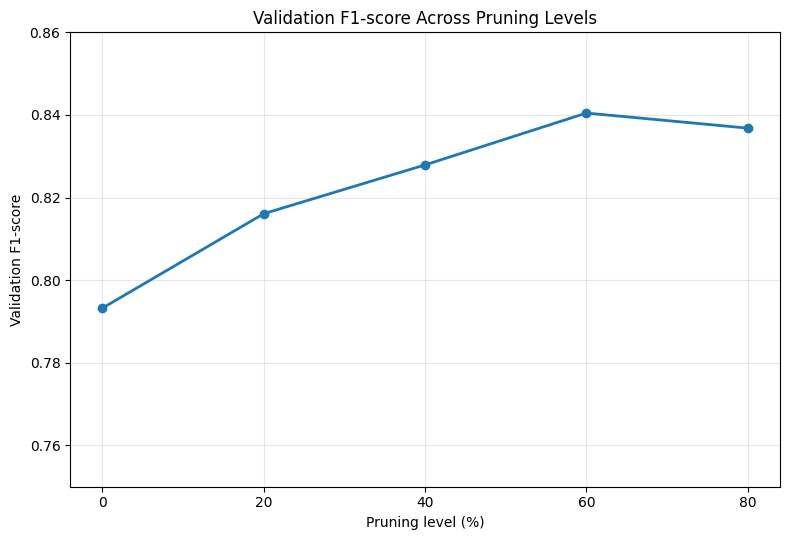

Highest pruning F1-score: 0.840459 at 60% pruning.

Note: This figure describes the frozen validation results only. It does not perform additional model selection.


In [ ]:
# Cell 5
# F1 SCORE VS PRUNING LEVEL
# Prepare plotting data


f1_pruning_plot = pd.DataFrame({
    "Pruning level": [0, 20, 40, 60, 80],
    "F1": [
        FROZEN_RESULTS["baseline_f1"],
        FROZEN_RESULTS["pruning_20_f1"],
        FROZEN_RESULTS["pruning_40_f1"],
        FROZEN_RESULTS["pruning_60_f1"],
        FROZEN_RESULTS["pruning_80_f1"]
    ]
})

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(figsize=(8, 5.5))

plt.plot(
    f1_pruning_plot["Pruning level"],
    f1_pruning_plot["F1"],
    marker="o",
    linewidth=2
)

plt.xlabel("Pruning level (%)")
plt.ylabel("Validation F1-score")
plt.title("Validation F1-score Across Pruning Levels")

plt.xticks([0, 20, 40, 60, 80])
plt.ylim(0.75, 0.86)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# Identify the highest frozen pruning F1
# ------------------------------------------------------------

best_pruning_row = pruning_results.loc[
    pruning_results["F1"].idxmax()
]

print(
    f"Highest pruning F1-score: "
    f"{best_pruning_row['F1']:.6f} "
    f"at {best_pruning_row['Pruning level']} pruning."
)

print(
    "\nNote: This figure describes the frozen validation results only. "
    "It does not perform additional model selection."
)

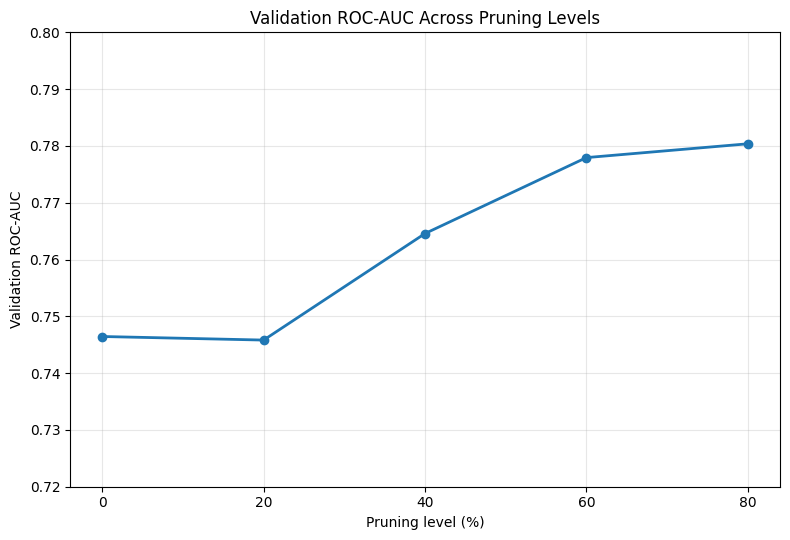

Highest pruning ROC-AUC: 0.780374 at 80% pruning.

Note: This figure describes the frozen validation results only. It does not perform additional model selection.


In [ ]:
# Cell 6
# NOTEBOOK 6 — ROC-AUC VS PRUNING LEVEL
# Prepare frozen ROC-AUC data

roc_auc_pruning_plot = pd.DataFrame({
    "Pruning level": [0, 20, 40, 60, 80],
    "ROC-AUC": [
        FROZEN_RESULTS["baseline_roc_auc"],
        FROZEN_RESULTS["pruning_20_roc_auc"],
        FROZEN_RESULTS["pruning_40_roc_auc"],
        FROZEN_RESULTS["pruning_60_roc_auc"],
        FROZEN_RESULTS["pruning_80_roc_auc"]
    ]
})

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(figsize=(8, 5.5))

plt.plot(
    roc_auc_pruning_plot["Pruning level"],
    roc_auc_pruning_plot["ROC-AUC"],
    marker="o",
    linewidth=2
)

plt.xlabel("Pruning level (%)")
plt.ylabel("Validation ROC-AUC")
plt.title("Validation ROC-AUC Across Pruning Levels")

plt.xticks([0, 20, 40, 60, 80])
plt.ylim(0.72, 0.80)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# Identify the highest frozen pruning ROC-AUC
# ------------------------------------------------------------

best_roc_auc_row = pruning_results.loc[
    pruning_results["ROC-AUC"].idxmax()
]

print(
    f"Highest pruning ROC-AUC: "
    f"{best_roc_auc_row['ROC-AUC']:.6f} "
    f"at {best_roc_auc_row['Pruning level']} pruning."
)

print(
    "\nNote: This figure describes the frozen validation results only. "
    "It does not perform additional model selection."
)

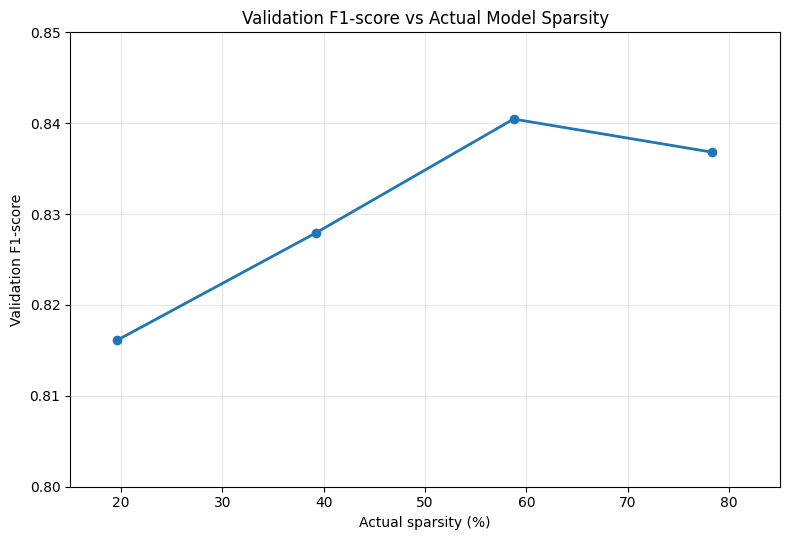

F1 VS ACTUAL SPARSITY


,Pruning level,Actual sparsity,F1
0,20% pruning,19.59%,0.816092
1,40% pruning,39.20%,0.827908
2,60% pruning,58.73%,0.840459
3,80% pruning,78.34%,0.836807



The actual sparsity values are taken directly from the frozen Notebook 5 pruning analyses.


In [ ]:
# Cell 7
# ============================================================
# NOTEBOOK 6 — F1 SCORE VS ACTUAL SPARSITY
# ============================================================

# ------------------------------------------------------------
# Frozen actual sparsity values from Notebook 5
# ------------------------------------------------------------

actual_sparsity_results = pd.DataFrame({
    "Pruning level": [
        "20% pruning",
        "40% pruning",
        "60% pruning",
        "80% pruning"
    ],

    "Actual sparsity": [
        0.195852,
        0.391966,
        0.587293,
        0.783408
    ],

    "F1": [
        FROZEN_RESULTS["pruning_20_f1"],
        FROZEN_RESULTS["pruning_40_f1"],
        FROZEN_RESULTS["pruning_60_f1"],
        FROZEN_RESULTS["pruning_80_f1"]
    ]
})

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(figsize=(8, 5.5))

plt.plot(
    actual_sparsity_results["Actual sparsity"] * 100,
    actual_sparsity_results["F1"],
    marker="o",
    linewidth=2
)

plt.xlabel("Actual sparsity (%)")
plt.ylabel("Validation F1-score")
plt.title("Validation F1-score vs Actual Model Sparsity")

plt.xlim(15, 85)
plt.ylim(0.80, 0.85)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# Display the exact values used in the figure
# ------------------------------------------------------------

print("=" * 90)
print("F1 VS ACTUAL SPARSITY")
print("=" * 90)

display(
    actual_sparsity_results.style.format({
        "Actual sparsity": "{:.2%}",
        "F1": "{:.6f}"
    })
)

print(
    "\nThe actual sparsity values are taken directly from the "
    "frozen Notebook 5 pruning analyses."
)

In [ ]:
# Cell 8
# ============================================================
# NOTEBOOK 6 — BASELINE VS QUANTISED CNN
# ============================================================

# ------------------------------------------------------------
# Frozen validation comparison
# ------------------------------------------------------------

quantisation_comparison = pd.DataFrame({
    "Configuration": [
        "Frozen baseline",
        "Quantised CNN"
    ],

    "F1": [
        FROZEN_RESULTS["baseline_f1"],
        FROZEN_RESULTS["quantised_f1"]
    ],

    "ROC-AUC": [
        FROZEN_RESULTS["baseline_roc_auc"],
        FROZEN_RESULTS["quantised_roc_auc"]
    ],

    "Prediction time (s)": [
        FROZEN_RESULTS["baseline_prediction_time"],
        FROZEN_RESULTS["quantised_prediction_time"]
    ]
})

# ------------------------------------------------------------
# Calculate performance changes
# ------------------------------------------------------------

f1_change = (
    FROZEN_RESULTS["quantised_f1"]
    - FROZEN_RESULTS["baseline_f1"]
)

roc_auc_change = (
    FROZEN_RESULTS["quantised_roc_auc"]
    - FROZEN_RESULTS["baseline_roc_auc"]
)

print("=" * 90)
print("FROZEN BASELINE VS QUANTISED CNN")
print("=" * 90)

display(
    quantisation_comparison.style.format({
        "F1": "{:.6f}",
        "ROC-AUC": "{:.6f}",
        "Prediction time (s)": "{:.6f}"
    })
)

print("\nPerformance change after quantisation:")
print(f"  Δ F1      : {f1_change:+.6f}")
print(f"  Δ ROC-AUC : {roc_auc_change:+.6f}")

print("\nFrozen efficiency measurements:")
print(
    f"  Model-size reduction      : "
    f"{FROZEN_RESULTS['model_size_reduction_percent']:.2f}%"
)
print(
    f"  Prediction-time reduction : "
    f"{FROZEN_RESULTS['prediction_time_reduction_percent']:.2f}%"
)
print(
    f"  Inference speed-up        : "
    f"{FROZEN_RESULTS['inference_speedup']:.3f}x"
)

print(
    "\nImportant: prediction-time measurements shown here are the "
    "paired validation measurements recorded in Notebook 5."
)

FROZEN BASELINE VS QUANTISED CNN


,Configuration,F1,ROC-AUC,Prediction time (s)
0,Frozen baseline,0.793242,0.746448,51.093595
1,Quantised CNN,0.788787,0.744670,27.691437



Performance change after quantisation:
  Δ F1      : -0.004455
  Δ ROC-AUC : -0.001778

Frozen efficiency measurements:
  Model-size reduction      : 34.10%
  Prediction-time reduction : 45.80%
  Inference speed-up        : 1.845x

Important: prediction-time measurements shown here are the paired validation measurements recorded in Notebook 5.


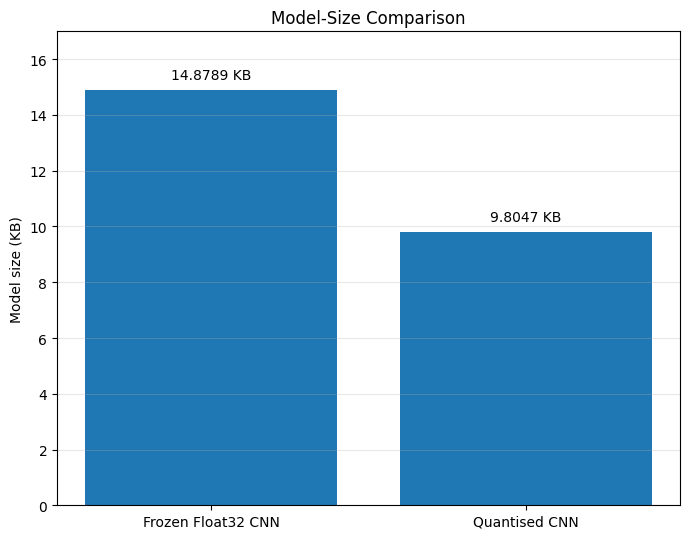

MODEL-SIZE EFFICIENCY
Baseline model size : 14.8789 KB
Quantised model size: 9.8047 KB
Measured reduction  : 34.10%

This is a storage-size measurement only. It does not by itself demonstrate hardware deployment performance.


In [ ]:
# Cell 9


model_size_comparison = pd.DataFrame({
    "Model": [
        "Frozen Float32 CNN",
        "Quantised CNN"
    ],
    "Model size (KB)": [
        14.8789,
        9.8047
    ]
})

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(figsize=(7, 5.5))

bars = plt.bar(
    model_size_comparison["Model"],
    model_size_comparison["Model size (KB)"]
)

plt.ylabel("Model size (KB)")
plt.title("Model-Size Comparison")

plt.ylim(0, 17)

# Add measured values above bars
for bar, value in zip(
    bars,
    model_size_comparison["Model size (KB)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{value:.4f} KB",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# Verify reduction
# ------------------------------------------------------------

baseline_size = model_size_comparison.loc[
    model_size_comparison["Model"] == "Frozen Float32 CNN",
    "Model size (KB)"
].iloc[0]

quantised_size = model_size_comparison.loc[
    model_size_comparison["Model"] == "Quantised CNN",
    "Model size (KB)"
].iloc[0]

calculated_reduction = (
    (baseline_size - quantised_size)
    / baseline_size
) * 100

print("=" * 80)
print("MODEL-SIZE EFFICIENCY")
print("=" * 80)

print(f"Baseline model size : {baseline_size:.4f} KB")
print(f"Quantised model size: {quantised_size:.4f} KB")
print(f"Measured reduction  : {calculated_reduction:.2f}%")

print(
    "\nThis is a storage-size measurement only. "
    "It does not by itself demonstrate hardware deployment performance."
)

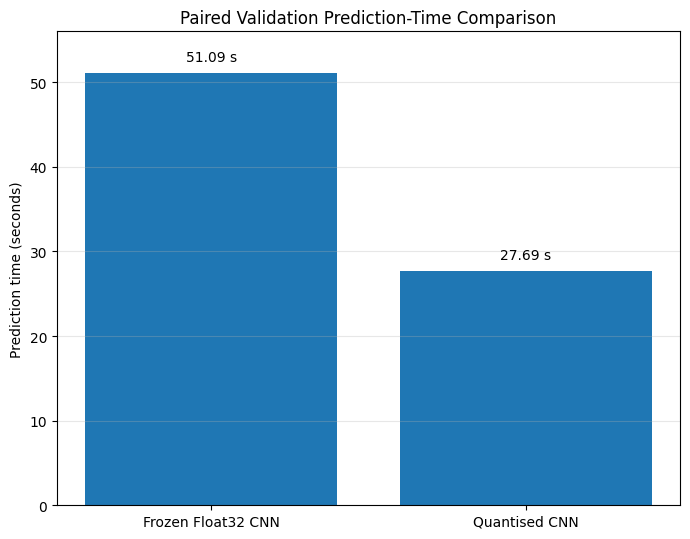

PREDICTION-TIME EFFICIENCY
Baseline prediction time : 51.093595 seconds
Quantised prediction time: 27.691437 seconds
Prediction-time reduction: 45.80%
Measured speed-up        : 1.845x

These are paired validation measurements from Notebook 5. They are not test-set measurements and are not used for additional model selection.


In [ ]:
# Cell 10


prediction_time_comparison = pd.DataFrame({
    "Model": [
        "Frozen Float32 CNN",
        "Quantised CNN"
    ],
    "Prediction time (s)": [
        51.093595,
        27.691437
    ]
})

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(figsize=(7, 5.5))

bars = plt.bar(
    prediction_time_comparison["Model"],
    prediction_time_comparison["Prediction time (s)"]
)

plt.ylabel("Prediction time (seconds)")
plt.title("Paired Validation Prediction-Time Comparison")

plt.ylim(0, 56)

# Add measured values above bars
for bar, value in zip(
    bars,
    prediction_time_comparison["Prediction time (s)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f} s",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# Calculate and verify efficiency change
# ------------------------------------------------------------

baseline_time = prediction_time_comparison.loc[
    prediction_time_comparison["Model"] == "Frozen Float32 CNN",
    "Prediction time (s)"
].iloc[0]

quantised_time = prediction_time_comparison.loc[
    prediction_time_comparison["Model"] == "Quantised CNN",
    "Prediction time (s)"
].iloc[0]

time_reduction = (
    (baseline_time - quantised_time)
    / baseline_time
) * 100

speedup = baseline_time / quantised_time

print("=" * 80)
print("PREDICTION-TIME EFFICIENCY")
print("=" * 80)

print(f"Baseline prediction time : {baseline_time:.6f} seconds")
print(f"Quantised prediction time: {quantised_time:.6f} seconds")
print(f"Prediction-time reduction: {time_reduction:.2f}%")
print(f"Measured speed-up        : {speedup:.3f}x")

print(
    "\nThese are paired validation measurements from Notebook 5. "
    "They are not test-set measurements and are not used for "
    "additional model selection."
)

In [ ]:
# Cell 11


print("=" * 90)
print("CHECKING AVAILABILITY OF FROZEN NOTEBOOK 5 TEST OBJECTS")
print("=" * 90)

# ------------------------------------------------------------
# Objects required for test-level and participant-level analysis
# ------------------------------------------------------------

required_objects = [
    "test_probabilities_35",
    "test_predictions_35",
    "test_labels_35",
    "dl_test"
]

availability = []

for object_name in required_objects:
    available = object_name in globals()

    availability.append({
        "Object": object_name,
        "Available in current runtime": "YES" if available else "NO"
    })

availability_df = pd.DataFrame(availability)

display(availability_df)

print("\nDetailed checks:")

# ------------------------------------------------------------
# Test probabilities
# ------------------------------------------------------------

if "test_probabilities_35" in globals():
    print(
        f"test_probabilities_35: "
        f"AVAILABLE — {len(test_probabilities_35):,} values"
    )
else:
    print("test_probabilities_35: NOT AVAILABLE")

# ------------------------------------------------------------
# Test predictions
# ------------------------------------------------------------

if "test_predictions_35" in globals():
    print(
        f"test_predictions_35: "
        f"AVAILABLE — {len(test_predictions_35):,} values"
    )
else:
    print("test_predictions_35: NOT AVAILABLE")

# ------------------------------------------------------------
# Test labels
# ------------------------------------------------------------

if "test_labels_35" in globals():
    print(
        f"test_labels_35: "
        f"AVAILABLE — {len(test_labels_35):,} values"
    )
else:
    print("test_labels_35: NOT AVAILABLE")

# ------------------------------------------------------------
# Held-out test metadata
# ------------------------------------------------------------

if "dl_test" in globals():
    print(
        f"dl_test: AVAILABLE — "
        f"{len(dl_test):,} rows"
    )

    if "ParticipantID" in dl_test.columns:
        print(
            f"Unique test participants: "
            f"{dl_test['ParticipantID'].nunique()}"
        )
else:
    print("dl_test: NOT AVAILABLE")

print("\n" + "=" * 90)
print("NO MODEL INFERENCE OR TEST EVALUATION WAS PERFORMED")
print("=" * 90)

print(
    "\nThis cell only checks the current Python runtime. "
    "It does not reconstruct, retrain, or rerun the frozen model."
)

CHECKING AVAILABILITY OF FROZEN NOTEBOOK 5 TEST OBJECTS


,Object,Available in current runtime
0,test_probabilities_35,NO
1,test_predictions_35,NO
2,test_labels_35,NO
3,dl_test,NO



Detailed checks:
test_probabilities_35: NOT AVAILABLE
test_predictions_35: NOT AVAILABLE
test_labels_35: NOT AVAILABLE
dl_test: NOT AVAILABLE

NO MODEL INFERENCE OR TEST EVALUATION WAS PERFORMED

This cell only checks the current Python runtime. It does not reconstruct, retrain, or rerun the frozen model.


In [ ]:
# Cell 12


from google.colab import files
import os

print("=" * 80)
print("UPLOAD FROZEN NOTEBOOK 5 TEST PREDICTIONS")
print("=" * 80)

uploaded = files.upload()

print("\nUploaded file(s):")

for filename in uploaded.keys():
    file_size = os.path.getsize(filename) / 1024

    print(f"  {filename}")
    print(f"  Size: {file_size:.2f} KB")

print("\nNo model inference was performed.")
print("No model was modified.")
print("=" * 80)


UPLOAD FROZEN NOTEBOOK 5 TEST PREDICTIONS


Saving Notebook5_Frozen_Test_Predictions.npz to Notebook5_Frozen_Test_Predictions.npz

Uploaded file(s):
  Notebook5_Frozen_Test_Predictions.npz
  Size: 1538.35 KB

No model inference was performed.
No model was modified.


In [ ]:
# Cell 13
# ============================================================
# NOTEBOOK 6 — LOAD AND VERIFY FROZEN TEST PREDICTIONS
# ============================================================

import numpy as np
import pandas as pd
import hashlib

# ------------------------------------------------------------
# Locate the uploaded frozen artifact
# ------------------------------------------------------------

prediction_file = "Notebook5_Frozen_Test_Predictions.npz"

# ------------------------------------------------------------
# Verify SHA-256 against the hash recorded in Notebook 5
# ------------------------------------------------------------

expected_sha256 = (
    "71d2f1b835febcaea41356e84db2843ea8c02a49cab67a98baebb292bf6de83b"
)

with open(prediction_file, "rb") as f:
    actual_sha256 = hashlib.sha256(f.read()).hexdigest()

if actual_sha256 != expected_sha256:
    raise RuntimeError(
        "SHA-256 mismatch. The uploaded prediction artifact "
        "does not match the frozen Notebook 5 artifact."
    )

# ------------------------------------------------------------
# Load frozen arrays
# ------------------------------------------------------------

frozen_test_data = np.load(
    prediction_file,
    allow_pickle=False
)

test_probabilities_frozen = frozen_test_data[
    "test_probabilities"
]

test_predictions_frozen = frozen_test_data[
    "test_predictions"
]

test_labels_frozen = frozen_test_data[
    "test_labels"
]

test_participant_ids_frozen = frozen_test_data[
    "participant_ids"
]

frozen_threshold = float(
    frozen_test_data["threshold"]
)

# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

expected_samples = 65_581

arrays = {
    "Probabilities": test_probabilities_frozen,
    "Predictions": test_predictions_frozen,
    "Labels": test_labels_frozen,
    "Participant IDs": test_participant_ids_frozen
}

for name, array in arrays.items():
    if len(array) != expected_samples:
        raise RuntimeError(
            f"{name}: expected {expected_samples:,}, "
            f"found {len(array):,}."
        )

if frozen_threshold != 0.5:
    raise RuntimeError(
        f"Expected threshold 0.5, found {frozen_threshold}."
    )

# ------------------------------------------------------------
# Verify binary predictions exactly match probabilities
# at the frozen 0.5 threshold
# ------------------------------------------------------------

reconstructed_predictions = (
    test_probabilities_frozen >= frozen_threshold
).astype(np.int32)

if not np.array_equal(
    reconstructed_predictions,
    test_predictions_frozen
):
    raise RuntimeError(
        "Stored predictions do not exactly match "
        "the stored probabilities at threshold 0.5."
    )

# ------------------------------------------------------------
# Verify held-out participant count
# ------------------------------------------------------------

unique_participants = np.unique(
    test_participant_ids_frozen
)

if len(unique_participants) != 5:
    raise RuntimeError(
        f"Expected 5 held-out participants, "
        f"found {len(unique_participants)}."
    )

# ------------------------------------------------------------
# Display verification
# ------------------------------------------------------------

print("=" * 90)
print("FROZEN NOTEBOOK 5 TEST ARTIFACT VERIFIED")
print("=" * 90)

print(f"SHA-256              : {actual_sha256}")
print(f"Test samples         : {expected_samples:,}")
print(f"Held-out participants: {len(unique_participants)}")
print(f"Frozen threshold     : {frozen_threshold}")

print("\nParticipant IDs:")
print(unique_participants)

print("\nIntegrity checks:")
print("✓ SHA-256 matches Notebook 5")
print("✓ 65,581 probabilities recovered")
print("✓ 65,581 predictions recovered")
print("✓ 65,581 true labels recovered")
print("✓ 65,581 participant IDs recovered")
print("✓ Threshold = 0.5")
print("✓ Predictions exactly reproduce from probabilities")
print("✓ Five held-out participants confirmed")
print("✓ No inference performed")
print("✓ No model retraining or modification performed")

print("=" * 90)

FROZEN NOTEBOOK 5 TEST ARTIFACT VERIFIED
SHA-256              : 71d2f1b835febcaea41356e84db2843ea8c02a49cab67a98baebb292bf6de83b
Test samples         : 65,581
Held-out participants: 5
Frozen threshold     : 0.5

Participant IDs:
[ 2  5  9 14 28]

Integrity checks:
✓ SHA-256 matches Notebook 5
✓ 65,581 probabilities recovered
✓ 65,581 predictions recovered
✓ 65,581 true labels recovered
✓ 65,581 participant IDs recovered
✓ Threshold = 0.5
✓ Predictions exactly reproduce from probabilities
✓ Five held-out participants confirmed
✓ No inference performed
✓ No model retraining or modification performed


In [ ]:
# Cell 14


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# ------------------------------------------------------------
# Calculate frozen test metrics
# ------------------------------------------------------------

test_accuracy_reconstructed = accuracy_score(
    test_labels_frozen,
    test_predictions_frozen
)

test_precision_reconstructed = precision_score(
    test_labels_frozen,
    test_predictions_frozen,
    zero_division=0
)

test_recall_reconstructed = recall_score(
    test_labels_frozen,
    test_predictions_frozen,
    zero_division=0
)

test_f1_reconstructed = f1_score(
    test_labels_frozen,
    test_predictions_frozen,
    zero_division=0
)

test_roc_auc_reconstructed = roc_auc_score(
    test_labels_frozen,
    test_probabilities_frozen
)

# ------------------------------------------------------------
# Compare against the frozen Notebook 5 final results
# ------------------------------------------------------------

frozen_test_metrics = {
    "Accuracy": 0.656852,
    "Precision": 0.899348,
    "Recall": 0.625804,
    "F1": 0.738045,
    "ROC-AUC": 0.773637
}

reconstructed_test_metrics = {
    "Accuracy": test_accuracy_reconstructed,
    "Precision": test_precision_reconstructed,
    "Recall": test_recall_reconstructed,
    "F1": test_f1_reconstructed,
    "ROC-AUC": test_roc_auc_reconstructed
}

comparison = pd.DataFrame({
    "Metric": list(frozen_test_metrics.keys()),
    "Notebook 5 frozen": list(frozen_test_metrics.values()),
    "Notebook 6 reconstructed": list(reconstructed_test_metrics.values())
})

comparison["Absolute difference"] = (
    comparison["Notebook 6 reconstructed"]
    - comparison["Notebook 5 frozen"]
).abs()

# ------------------------------------------------------------
# Strict consistency check
# ------------------------------------------------------------

tolerance = 1e-6

if (
    comparison["Absolute difference"] > tolerance
).any():
    raise RuntimeError(
        "Reconstructed metrics do not match the frozen "
        "Notebook 5 results within the required tolerance."
    )

# ------------------------------------------------------------
# Display comparison
# ------------------------------------------------------------

print("=" * 100)
print("FINAL QUANTISED CNN — HELD-OUT TEST METRICS")
print("=" * 100)

display(
    comparison.style.format({
        "Notebook 5 frozen": "{:.6f}",
        "Notebook 6 reconstructed": "{:.6f}",
        "Absolute difference": "{:.10f}"
    })
)

print("\nClassification report:")
print(
    classification_report(
        test_labels_frozen,
        test_predictions_frozen,
        target_names=["Class 0", "Class 1"],
        digits=6,
        zero_division=0
    )
)

print("=" * 100)
print("✓ Reconstructed metrics match the frozen Notebook 5 results.")
print("✓ No model inference was performed.")
print("✓ No test-set model selection was performed.")
print("=" * 100)

FINAL QUANTISED CNN — HELD-OUT TEST METRICS


,Metric,Notebook 5 frozen,Notebook 6 reconstructed,Absolute difference
0,Accuracy,0.656852,0.656852,0.0000001679
1,Precision,0.899348,0.899348,0.0000004823
2,Recall,0.625804,0.625804,0.0000004139
3,F1,0.738045,0.738045,0.0000003508
4,ROC-AUC,0.773637,0.773637,0.0000004486



Classification report:
              precision    recall  f1-score   support

     Class 0   0.375029  0.762246  0.502718     14923
     Class 1   0.899348  0.625804  0.738045     50658

    accuracy                       0.656852     65581
   macro avg   0.637188  0.694025  0.620382     65581
weighted avg   0.780038  0.656852  0.684496     65581

✓ Reconstructed metrics match the frozen Notebook 5 results.
✓ No model inference was performed.
✓ No test-set model selection was performed.


FINAL QUANTISED CNN — TEST CONFUSION MATRIX


,Predicted Class 0,Predicted Class 1
Actual Class 0,11375,3548
Actual Class 1,18956,31702


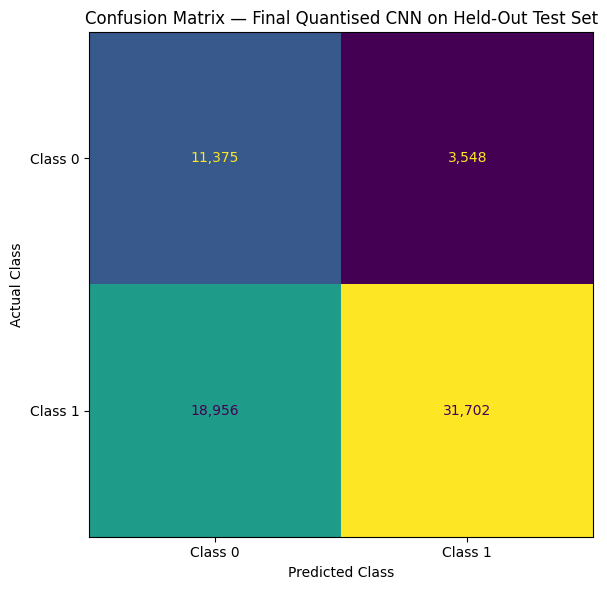


Confusion-matrix components:
True Negatives  (TN): 11,375
False Positives (FP): 3,548
False Negatives (FN): 18,956
True Positives  (TP): 31,702

Test-set size:
65,581 samples

Note: The confusion matrix is descriptive of the frozen held-out test predictions. It is not used for model selection.


In [ ]:
# Cell 15


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ------------------------------------------------------------
# Calculate confusion matrix from frozen predictions
# ------------------------------------------------------------

cm_final = confusion_matrix(
    test_labels_frozen,
    test_predictions_frozen,
    labels=[0, 1]
)

# ------------------------------------------------------------
# Display numerical confusion matrix
# ------------------------------------------------------------

cm_table = pd.DataFrame(
    cm_final,
    index=["Actual Class 0", "Actual Class 1"],
    columns=["Predicted Class 0", "Predicted Class 1"]
)

print("=" * 80)
print("FINAL QUANTISED CNN — TEST CONFUSION MATRIX")
print("=" * 80)

display(cm_table)

# ------------------------------------------------------------
# Create dissertation-ready visualisation
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["Class 0", "Class 1"]
)

disp.plot(
    ax=ax,
    values_format=",d",
    colorbar=False
)

ax.set_title(
    "Confusion Matrix — Final Quantised CNN on Held-Out Test Set"
)

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Print interpretation components
# ------------------------------------------------------------

tn, fp, fn, tp = cm_final.ravel()

print("\nConfusion-matrix components:")
print(f"True Negatives  (TN): {tn:,}")
print(f"False Positives (FP): {fp:,}")
print(f"False Negatives (FN): {fn:,}")
print(f"True Positives  (TP): {tp:,}")

print("\nTest-set size:")
print(f"{cm_final.sum():,} samples")

print(
    "\nNote: The confusion matrix is descriptive of the frozen "
    "held-out test predictions. It is not used for model selection."
)

In [ ]:
# Cell 16
# ============================================================
# NOTEBOOK 6 — HELD-OUT TEST SAMPLE DISTRIBUTION
# ============================================================

# ------------------------------------------------------------
# Construct participant-level sample counts
# ------------------------------------------------------------

participant_sample_counts = (
    pd.Series(test_participant_ids_frozen, name="ParticipantID")
    .value_counts()
    .sort_index()
    .rename("Test samples")
    .reset_index()
)

# ------------------------------------------------------------
# Calculate percentage of total test set
# ------------------------------------------------------------

participant_sample_counts["Percentage of test set (%)"] = (
    participant_sample_counts["Test samples"]
    / len(test_participant_ids_frozen)
    * 100
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 90)
print("HELD-OUT TEST SAMPLE DISTRIBUTION BY PARTICIPANT")
print("=" * 90)

display(
    participant_sample_counts.style.format({
        "Test samples": "{:,}",
        "Percentage of test set (%)": "{:.2f}%"
    })
)

print(
    f"\nTotal test samples: "
    f"{participant_sample_counts['Test samples'].sum():,}"
)

print(
    f"Number of held-out participants: "
    f"{len(participant_sample_counts)}"
)

print(
    "\nNote: This table describes the composition of the frozen "
    "held-out test set. It does not evaluate or select the model."
)

HELD-OUT TEST SAMPLE DISTRIBUTION BY PARTICIPANT


,ParticipantID,Test samples,Percentage of test set (%)
0,2,"14,799",22.57%
1,5,"14,170",21.61%
2,9,"14,415",21.98%
3,14,"8,487",12.94%
4,28,"13,710",20.91%



Total test samples: 65,581
Number of held-out participants: 5

Note: This table describes the composition of the frozen held-out test set. It does not evaluate or select the model.


In [ ]:
# Cell 17


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------------------
# Calculate participant-level metrics
# ------------------------------------------------------------

participant_metrics = []

for participant_id in unique_participants:

    mask = (
        test_participant_ids_frozen == participant_id
    )

    participant_labels = test_labels_frozen[mask]
    participant_predictions = test_predictions_frozen[mask]
    participant_probabilities = test_probabilities_frozen[mask]

    # Check whether both classes are present
    unique_labels = np.unique(participant_labels)

    if len(unique_labels) == 2:
        participant_roc_auc = roc_auc_score(
            participant_labels,
            participant_probabilities
        )
    else:
        participant_roc_auc = np.nan

    participant_metrics.append({
        "ParticipantID": participant_id,
        "Test samples": len(participant_labels),
        "Positive prevalence (%)": (
            np.mean(participant_labels) * 100
        ),
        "Accuracy": accuracy_score(
            participant_labels,
            participant_predictions
        ),
        "Precision": precision_score(
            participant_labels,
            participant_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            participant_labels,
            participant_predictions,
            zero_division=0
        ),
        "F1": f1_score(
            participant_labels,
            participant_predictions,
            zero_division=0
        ),
        "ROC-AUC": participant_roc_auc
    })

participant_metrics_df = pd.DataFrame(
    participant_metrics
)

# ------------------------------------------------------------
# Display participant-level results
# ------------------------------------------------------------

print("=" * 110)
print("FINAL QUANTISED CNN — PARTICIPANT-LEVEL TEST PERFORMANCE")
print("=" * 110)

display(
    participant_metrics_df.style.format({
        "Test samples": "{:,}",
        "Positive prevalence (%)": "{:.2f}%",
        "Accuracy": "{:.6f}",
        "Precision": "{:.6f}",
        "Recall": "{:.6f}",
        "F1": "{:.6f}",
        "ROC-AUC": lambda x: (
            "Not defined"
            if pd.isna(x)
            else f"{x:.6f}"
        )
    })
)

# ------------------------------------------------------------
# Summarise variability
# ------------------------------------------------------------

print("\nParticipant-level variability:")

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]:

    values = participant_metrics_df[metric].dropna()

    print(
        f"{metric:<12} "
        f"Mean = {values.mean():.6f} | "
        f"SD = {values.std(ddof=1):.6f} | "
        f"Range = {values.min():.6f}–{values.max():.6f}"
    )

print(
    "\nImportant: Participant-level metrics are descriptive only. "
    "The five participants were not used for model selection or tuning."
)

FINAL QUANTISED CNN — PARTICIPANT-LEVEL TEST PERFORMANCE


,ParticipantID,Test samples,Positive prevalence (%),Accuracy,Precision,Recall,F1,ROC-AUC
0,2,"14,799",72.51%,0.713156,0.815038,0.781847,0.798098,0.697152
1,5,"14,170",64.03%,0.484051,0.805479,0.256034,0.388559,0.789251
2,9,"14,415",82.53%,0.847451,0.909060,0.905775,0.907414,0.835492
3,14,"8,487",95.76%,0.657123,1.000000,0.641934,0.781924,0.741954
4,28,"13,710",78.99%,0.574106,0.999000,0.461311,0.631167,0.985186



Participant-level variability:
Accuracy     Mean = 0.655177 | SD = 0.138014 | Range = 0.484051–0.847451
Precision    Mean = 0.905715 | SD = 0.094700 | Range = 0.805479–1.000000
Recall       Mean = 0.609380 | SD = 0.257600 | Range = 0.256034–0.905775
F1           Mean = 0.701432 | SD = 0.200673 | Range = 0.388559–0.907414
ROC-AUC      Mean = 0.809807 | SD = 0.110832 | Range = 0.697152–0.985186

Important: Participant-level metrics are descriptive only. The five participants were not used for model selection or tuning.


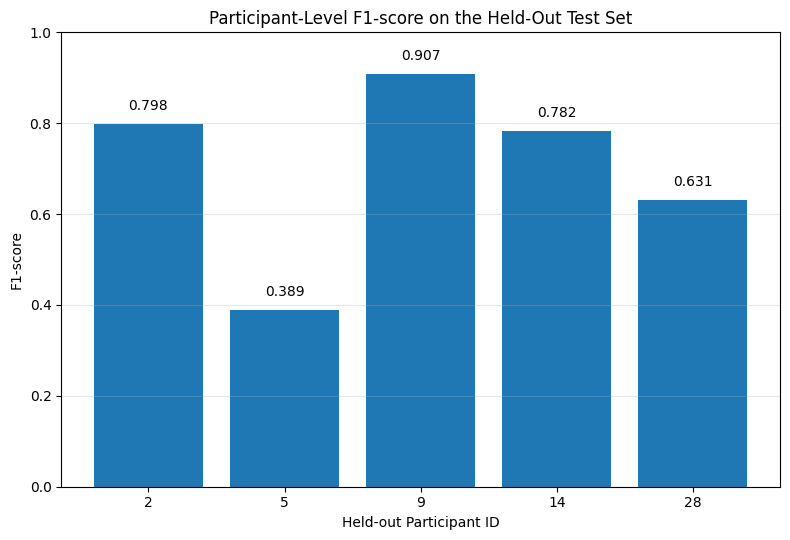

PARTICIPANT-LEVEL F1 VARIABILITY
Lowest F1 : 0.388559 (Participant 5)
Highest F1: 0.907414 (Participant 9)
F1 range  : 0.518855

Interpretation note: With only five held-out participants, this variability is descriptive and should not be treated as a population-level estimate of generalisation.


In [ ]:
# Cell 18


plt.figure(figsize=(8, 5.5))

bars = plt.bar(
    participant_metrics_df["ParticipantID"].astype(str),
    participant_metrics_df["F1"]
)

plt.xlabel("Held-out Participant ID")
plt.ylabel("F1-score")
plt.title("Participant-Level F1-score on the Held-Out Test Set")

plt.ylim(0, 1.0)

# Add F1 values above bars
for bar, value in zip(
    bars,
    participant_metrics_df["F1"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.025,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# Identify range of participant-level F1
# ------------------------------------------------------------

f1_min = participant_metrics_df["F1"].min()
f1_max = participant_metrics_df["F1"].max()

min_participant = participant_metrics_df.loc[
    participant_metrics_df["F1"].idxmin(),
    "ParticipantID"
]

max_participant = participant_metrics_df.loc[
    participant_metrics_df["F1"].idxmax(),
    "ParticipantID"
]

print("=" * 85)
print("PARTICIPANT-LEVEL F1 VARIABILITY")
print("=" * 85)

print(
    f"Lowest F1 : {f1_min:.6f} "
    f"(Participant {min_participant})"
)

print(
    f"Highest F1: {f1_max:.6f} "
    f"(Participant {max_participant})"
)

print(
    f"F1 range  : {f1_max - f1_min:.6f}"
)

print(
    "\nInterpretation note: With only five held-out participants, "
    "this variability is descriptive and should not be treated "
    "as a population-level estimate of generalisation."
)

In [ ]:
# Cell 19

validation_test_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],

    "Quantised CNN — Validation": [
        np.nan,
        np.nan,
        FROZEN_RESULTS["quantised_recall"],
        FROZEN_RESULTS["quantised_f1"],
        FROZEN_RESULTS["quantised_roc_auc"]
    ],

    "Quantised CNN — Held-out Test": [
        test_accuracy_reconstructed,
        test_precision_reconstructed,
        test_recall_reconstructed,
        test_f1_reconstructed,
        test_roc_auc_reconstructed
    ]
})

# ------------------------------------------------------------
# Calculate differences where both metrics are available
# ------------------------------------------------------------

validation_test_comparison["Test − Validation"] = (
    validation_test_comparison[
        "Quantised CNN — Held-out Test"
    ]
    - validation_test_comparison[
        "Quantised CNN — Validation"
    ]
)

# Accuracy and precision were not recorded as part of the
# frozen validation comparison, so their differences remain
# undefined.
validation_test_comparison.loc[
    validation_test_comparison["Metric"].isin(
        ["Accuracy", "Precision"]
    ),
    "Test − Validation"
] = np.nan

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 100)
print("QUANTISED CNN — VALIDATION VS HELD-OUT TEST PERFORMANCE")
print("=" * 100)

display(
    validation_test_comparison.style.format({
        "Quantised CNN — Validation": lambda x:
            "Not recorded"
            if pd.isna(x) else f"{x:.6f}",
        "Quantised CNN — Held-out Test": "{:.6f}",
        "Test − Validation": lambda x:
            "Not comparable"
            if pd.isna(x) else f"{x:+.6f}"
    })
)

print("\nInterpretation note:")
print(
    "Validation and held-out test results are reported separately. "
    "The held-out test set contains only five participants and was "
    "accessed after model selection."
)

print(
    "\nAccuracy and precision were not recorded in the frozen "
    "validation comparison and are therefore not inferred here."
)

QUANTISED CNN — VALIDATION VS HELD-OUT TEST PERFORMANCE


,Metric,Quantised CNN — Validation,Quantised CNN — Held-out Test,Test − Validation
0,Accuracy,Not recorded,0.656852,Not comparable
1,Precision,Not recorded,0.899348,Not comparable
2,Recall,0.697309,0.625804,-0.071505
3,F1,0.788787,0.738045,-0.050742
4,ROC-AUC,0.744670,0.773637,+0.028967



Interpretation note:
Validation and held-out test results are reported separately. The held-out test set contains only five participants and was accessed after model selection.

Accuracy and precision were not recorded in the frozen validation comparison and are therefore not inferred here.


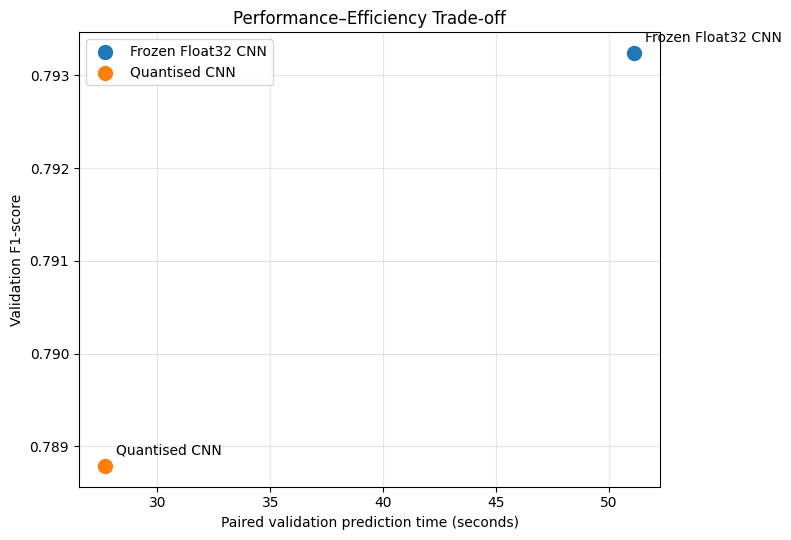

PERFORMANCE–EFFICIENCY TRADE-OFF
Validation F1 change          : -0.004455
Relative F1 change            : -0.56%
Prediction-time reduction     : 45.80%
Inference speed-up            : 1.845x
Model-size reduction          : 34.10%

Interpretation note:
The plot uses only the paired validation timing measurements that are directly comparable between the frozen Float32 baseline and Quantised CNN. Pruning evaluation-time measurements are intentionally excluded.


In [ ]:
# Cell 20
# ============================================================
# NOTEBOOK 6 — PERFORMANCE–EFFICIENCY TRADE-OFF
# ============================================================

# ------------------------------------------------------------
# Frozen validation performance and paired timing measurements
# ------------------------------------------------------------

tradeoff_df = pd.DataFrame({
    "Model": [
        "Frozen Float32 CNN",
        "Quantised CNN"
    ],

    "Validation F1": [
        FROZEN_RESULTS["baseline_f1"],
        FROZEN_RESULTS["quantised_f1"]
    ],

    "Prediction time (s)": [
        FROZEN_RESULTS["baseline_prediction_time"],
        FROZEN_RESULTS["quantised_prediction_time"]
    ]
})

# ------------------------------------------------------------
# Create trade-off plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5.5))

for _, row in tradeoff_df.iterrows():
    plt.scatter(
        row["Prediction time (s)"],
        row["Validation F1"],
        s=100,
        label=row["Model"]
    )

    plt.annotate(
        row["Model"],
        (
            row["Prediction time (s)"],
            row["Validation F1"]
        ),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel("Paired validation prediction time (seconds)")
plt.ylabel("Validation F1-score")
plt.title("Performance–Efficiency Trade-off")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Quantify the observed trade-off
# ------------------------------------------------------------

f1_change_absolute = (
    FROZEN_RESULTS["quantised_f1"]
    - FROZEN_RESULTS["baseline_f1"]
)

f1_change_relative = (
    f1_change_absolute
    / FROZEN_RESULTS["baseline_f1"]
) * 100

prediction_time_reduction = (
    (
        FROZEN_RESULTS["baseline_prediction_time"]
        - FROZEN_RESULTS["quantised_prediction_time"]
    )
    / FROZEN_RESULTS["baseline_prediction_time"]
) * 100

print("=" * 90)
print("PERFORMANCE–EFFICIENCY TRADE-OFF")
print("=" * 90)

print(
    f"Validation F1 change          : "
    f"{f1_change_absolute:+.6f}"
)

print(
    f"Relative F1 change            : "
    f"{f1_change_relative:+.2f}%"
)

print(
    f"Prediction-time reduction     : "
    f"{prediction_time_reduction:.2f}%"
)

print(
    f"Inference speed-up            : "
    f"{FROZEN_RESULTS['inference_speedup']:.3f}x"
)

print(
    f"Model-size reduction          : "
    f"{FROZEN_RESULTS['model_size_reduction_percent']:.2f}%"
)

print(
    "\nInterpretation note:"
    "\nThe plot uses only the paired validation timing measurements "
    "that are directly comparable between the frozen Float32 "
    "baseline and Quantised CNN. Pruning evaluation-time "
    "measurements are intentionally excluded."
)

In [ ]:
# Cell 21
# ============================================================
# NOTEBOOK 6 — FROZEN PRUNING RESULTS SUMMARY
# ============================================================

# ------------------------------------------------------------
# Frozen pruning results from Notebook 5
# ------------------------------------------------------------

pruning_summary = pd.DataFrame({
    "Pruning level (%)": [
        0,
        20,
        40,
        60,
        80
    ],

    "Actual sparsity (%)": [
        0.00,
        19.59,
        39.20,
        58.73,
        78.34
    ],

    "Validation F1": [
        0.793242,
        0.816092,
        0.827908,
        0.840459,
        0.836807
    ],

    "Validation ROC-AUC": [
        0.746448,
        0.745819,
        0.764577,
        0.777945,
        0.780374
    ]
})

# ------------------------------------------------------------
# Identify best pruning level for each validation metric
# ------------------------------------------------------------

best_f1_row = pruning_summary.loc[
    pruning_summary["Validation F1"].idxmax()
]

best_roc_auc_row = pruning_summary.loc[
    pruning_summary["Validation ROC-AUC"].idxmax()
]

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 100)
print("FROZEN PRUNING RESULTS SUMMARY")
print("=" * 100)

display(
    pruning_summary.style.format({
        "Pruning level (%)": "{:.0f}%",
        "Actual sparsity (%)": "{:.2f}%",
        "Validation F1": "{:.6f}",
        "Validation ROC-AUC": "{:.6f}"
    })
)

print("\nHighest validation F1:")
print(
    f"  {best_f1_row['Pruning level (%)']:.0f}% pruning | "
    f"Actual sparsity = {best_f1_row['Actual sparsity (%)']:.2f}% | "
    f"F1 = {best_f1_row['Validation F1']:.6f}"
)

print("\nHighest validation ROC-AUC:")
print(
    f"  {best_roc_auc_row['Pruning level (%)']:.0f}% pruning | "
    f"Actual sparsity = {best_roc_auc_row['Actual sparsity (%)']:.2f}% | "
    f"ROC-AUC = {best_roc_auc_row['Validation ROC-AUC']:.6f}"
)

print(
    "\nNote: These are frozen validation results from Notebook 5. "
    "They are descriptive and are not being re-optimised in Notebook 6."
)

FROZEN PRUNING RESULTS SUMMARY


,Pruning level (%),Actual sparsity (%),Validation F1,Validation ROC-AUC
0,0%,0.00%,0.793242,0.746448
1,20%,19.59%,0.816092,0.745819
2,40%,39.20%,0.827908,0.764577
3,60%,58.73%,0.840459,0.777945
4,80%,78.34%,0.836807,0.780374



Highest validation F1:
  60% pruning | Actual sparsity = 58.73% | F1 = 0.840459

Highest validation ROC-AUC:
  80% pruning | Actual sparsity = 78.34% | ROC-AUC = 0.780374

Note: These are frozen validation results from Notebook 5. They are descriptive and are not being re-optimised in Notebook 6.


In [ ]:
# Cell 22
# ============================================================
# NOTEBOOK 6 — FINAL DISSERTATION-READY RESULTS TABLE
# ============================================================

# ------------------------------------------------------------
# Frozen final experimental results
# ------------------------------------------------------------

final_results_table = pd.DataFrame({
    "Configuration": [
        "Frozen Float32 CNN",
        "20% pruning",
        "40% pruning",
        "60% pruning",
        "80% pruning",
        "Quantised CNN"
    ],

    "Validation F1": [
        0.793242,
        0.816092,
        0.827908,
        0.840459,
        0.836807,
        0.788787
    ],

    "Validation ROC-AUC": [
        0.746448,
        0.745819,
        0.764577,
        0.777945,
        0.780374,
        0.744670
    ],

    "Actual sparsity (%)": [
        0.00,
        19.59,
        39.20,
        58.73,
        78.34,
        np.nan
    ],

    "Model size (KB)": [
        14.8789,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        9.8047
    ],

    "Paired prediction time (s)": [
        51.093595,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        27.691437
    ]
})

# ------------------------------------------------------------
# Display table
# ------------------------------------------------------------

print("=" * 120)
print("FINAL DISSERTATION-READY RESULTS TABLE")
print("=" * 120)

display(
    final_results_table.style.format({
        "Validation F1": "{:.6f}",
        "Validation ROC-AUC": "{:.6f}",
        "Actual sparsity (%)": lambda x:
            "—" if pd.isna(x) else f"{x:.2f}%",
        "Model size (KB)": lambda x:
            "—" if pd.isna(x) else f"{x:.4f}",
        "Paired prediction time (s)": lambda x:
            "—" if pd.isna(x) else f"{x:.6f}"
    })
)

print("\nFrozen final test performance of the selected Quantised CNN:")
print(f"  Accuracy : {test_accuracy_reconstructed:.6f}")
print(f"  Precision: {test_precision_reconstructed:.6f}")
print(f"  Recall   : {test_recall_reconstructed:.6f}")
print(f"  F1       : {test_f1_reconstructed:.6f}")
print(f"  ROC-AUC  : {test_roc_auc_reconstructed:.6f}")

print(
    "\nImportant:"
    "\n• Test metrics belong only to the selected Quantised CNN."
    "\n• Test metrics were not used for model selection."
    "\n• Missing pruning efficiency values are intentionally not inferred."
    "\n• Timing comparisons are restricted to the directly paired "
    "Float32-versus-Quantised measurements."
)

print("=" * 120)

FINAL DISSERTATION-READY RESULTS TABLE


,Configuration,Validation F1,Validation ROC-AUC,Actual sparsity (%),Model size (KB),Paired prediction time (s)
0,Frozen Float32 CNN,0.793242,0.746448,0.00%,14.8789,51.093595
1,20% pruning,0.816092,0.745819,19.59%,—,—
2,40% pruning,0.827908,0.764577,39.20%,—,—
3,60% pruning,0.840459,0.777945,58.73%,—,—
4,80% pruning,0.836807,0.780374,78.34%,—,—
5,Quantised CNN,0.788787,0.744670,—,9.8047,27.691437



Frozen final test performance of the selected Quantised CNN:
  Accuracy : 0.656852
  Precision: 0.899348
  Recall   : 0.625804
  F1       : 0.738045
  ROC-AUC  : 0.773637

Important:
• Test metrics belong only to the selected Quantised CNN.
• Test metrics were not used for model selection.
• Missing pruning efficiency values are intentionally not inferred.
• Timing comparisons are restricted to the directly paired Float32-versus-Quantised measurements.


## Scientific Interpretation of the Final Experimental Results

Final Experimental Results and Their Scientific Interpretation The frozen experimental results showed that model optimization had differing effects on the validation performance of models. Optimization through pruning improved validation performance up to an intermediate level of sparsity; whereas, post-training quantization significantly improved the computational efficiency of the models while minimally reducing their predictive capability. For pruning, validation F1 rose from 0.793242 (for the frozen Float32 CNN) to 0.840459 (at 60% pruning), which corresponds to 58.73% actual sparsity. Validation F1 dropped slightly to 0.836807 (at 80% pruning). This indicates that the relationship between increasing sparsity and improving validation F1-score is non-monotonic. Conversely, ROC-AUC rose continuously over the evaluated pruning levels, and reached 0.780374 (at 80% pruning).

Thus, F1 and ROC-AUC measure different aspects of the pruning process and there is no single pruning level that maximizes both metrics. The Quantised CNN obtained a validation F1-score of 0.788787 and ROC-AUC of 0.744670. Relative to the frozen Float32 baseline, this represented small absolute decreases in validation F1 of 0.004455 and in validation ROC-AUC of 0.001778.

On the other hand, quantization led to reductions in the measured model size from 14.8789 KB to 9.8047 KB (a reduction of 34.10%) and in the paired validation prediction time from 51.093595 seconds to 27.691437 seconds (a reduction of 45.80% and a measured speed-up of 1.845×). These results highlight the core performance-efficiency tradeoff examined in this research. The quantised model did not obtain the highest validation predictive performance among the optimization configurations but it provided substantial measured improvements in efficiency while maintaining comparable validation F1 and ROC-AUC to the frozen baseline.

Therefore, the results illustrate that computational efficiency can be enhanced at the expense of relatively minor decreases in selected validation performance metrics.

Additionally, the final held-out evaluation provides further insight into generalizability. The Quantised CNN achieved an accuracy of 0.656852, precision of 0.899348, recall of 0.625804, F1-score of 0.738045 and ROC-AUC of 0.773637 on 65,581 samples from five participants who had been previously held out. In comparison to validation, F1 and recall were lower on the held-out test set while ROC-AUC was higher. Due to the limited number of participants included in the test set (i.e. only five), these differences should be interpreted cautiously.

Furthermore, participant-level analysis illustrates considerable variation in performance. F1-score ranged from 0.388559 to 0.907414 across the five held-out participants. This suggests that the aggregate test performance does not accurately reflect how every individual participant performed.

Consequently, participant-level variability should be considered when addressing participant-level generalizability.

However, given that only five participants were held out, these observations should be viewed as descriptive and not indicative of population-level generalizability.

In summary, the frozen results indicate a complex relationship between optimization methods and validation performance. Pruning demonstrated that large amounts of sparsity can be introduced into a model without negatively affecting validation F1 and, at intermediate levels of sparsity, can positively affect validation F1. Quantization exhibited the most clear-cut measured efficiency advantage, reducing both the measured model size and paired prediction time significantly while causing only minimal degradation to validation performance relative to the Float32 baseline. The held-out participant analysis also demonstrated that aggregate predictive performance can obscure meaningful participant-level variability.

## Limitations The following limitations need to be considered when evaluating the experimental findings: ### 1. Limited Number of Held-Out Participants The test set contains 65,581 ECG signals from only 5 participants.

While the total number of signal windows (i.e., data points) is large, the number of unique participants is small.

Therefore, participant-level findings should be evaluated as descriptive evidence of variability, not as statistically representative estimates of the population-level generalizability of findings. ### 2. Participant-Level Variability The participant-level analysis indicated significant variability in predictive performance among participants. F1-scores ranged from 0.388559 to 0.907414.

Thus, aggregate measures of performance can obscure differences in performance between participants.

However, due to the limited number of held-out participants, it was not possible to draw meaningful conclusions about the frequency or causes of such variability across a larger population. ### 3. Validation and Test Sets Have Different Functions The held-out test set was only accessed after validation-based model selection. Test performance did not influence model selection, parameter tuning, choice of optimization level, or modification of the classification threshold.

Therefore, the test results should be viewed as an assessment of the selected Quantized CNN, not as an outcome of optimization. ### 4. Differences in Optimization Objectives The pruning experiments and quantizing experiment assessed distinct aspects of lightweight optimization. Pruning caused changes in validation predictive performance and sparsity. Quantizing yielded directly observable model-size and prediction-time reductions. Timing data collected for pruning could not be compared directly to TFLite prediction-time data.

Consequently, assessments of efficiency are limited to comparisons between baseline and quantized models. ### 5. Environment-Dependent Efficiency Assessments The prediction times were recorded within the experimental environment used in this study. Prediction time can vary with software versions, processor characteristics, memory conditions, runtime implementations, and other execution factors.

Thus, the 45.80% reduction in prediction time and 1.845x increase in speed reported here should be viewed as empirically derived results, not as universally applicable performance guarantees for hardware-agnostic applications. ### 6. No Direct Assessment of Performance on Wearable Devices or Embedded Hardware Platforms The study evaluated software-based model optimization and computational characteristics. It did not directly assess performance on a wearable device or embedded hardware platform.

Therefore, the results should not be used as evidence of successful implementation on actual wearable devices. ### 7. No Clinical Use Claim The classification metrics presented in this study describe model behavior on the experimental dataset and do not represent evidence of clinical efficacy, diagnostic reliability or suitability for use in medical decision-making. Before claiming clinical efficacy, further validation on appropriately designed clinical datasets would be required. ### 8. Metric-Dependence of Interpretations The pruning results indicate that the level yielding the highest validation F1-score was not equivalent to the level yielding the highest validation ROC-AUC score. This indicates that interpretations regarding optimization depend somewhat on which evaluation metric is considered.

Therefore, both metrics are reported in this study rather than assuming one metric provides a complete representation of model performance. ### 9. Scope of the Frozen Experimental Record Notebook 6 represents an analysis/interpretation phase rather than an additional optimization phase. No new training, pruning, quantization, threshold tuning or test set model selection occurred.

Therefore, conclusions drawn from Notebook 6 are restricted to those established in Notebook 5's frozen record of experimental configurations and measurements.

## Final Conclusion

The objective of this research was to assess the impact of lightweight optimization on the ECG classification model based on the relationship between predictive performance and computational efficiency. The experimental results show that both pruning and post-training quantization affect the properties of the CNN; however, their effects differ in terms of the predictive performance and measured efficiency. The pruning experiments showed that moderate amounts of sparsity could improve validation performance. Validation F1 increased from 0.793242 for the frozen float32 CNN to a peak of 0.840459 at 60% pruning, representing 58.73% actual sparsity. At 80% pruning, F1 dropped slightly to 0.836807, and ROC-AUC reached its highest level of 0.780374.

Therefore, increasing sparsity does not necessarily lead to a continuous improvement among all evaluation metrics. The selected quantized CNN showed the clearest measured efficiency improvement. Compared to the frozen float32 baseline, the model size reduced by 34.10% and the paired validation prediction time decreased by 45.80%, which represents a measured 1.845x speed-up. These efficiency gains came at the expense of relatively small decreases in validation F1 and ROC-AUC, with decreases of 0.004455 and 0.001778, respectively.

Thus, the results illustrate a measurable trade-off between performance and efficiency, rather than an unconstrained improvement in each objective. The final held-out evaluation of the selected quantized CNN achieved an accuracy of 0.656852, precision of 0.899348, recall of 0.625804, F1-score of 0.738045 and ROC-AUC of 0.773637.

Importantly, these results were achieved using data collected from five participants that were independent of the model development process. Participant-level analyses revealed substantial variability in F1-score, ranging from 0.388559 to 0.907414.

Therefore, aggregate test performance can mask significant variations in model behavior across participants. Collectively, the results support the use of lightweight optimization to reduce measured computational requirements while preserving sufficient predictive performance within the experimental context. Quantization proved particularly effective at reducing model size and paired prediction time; whereas, pruning demonstrated that considerable sparsity can be introduced into the model without significantly impacting validation F1.

Nevertheless, the limited number of participants used for held-out evaluation, environment-dependent efficiency measurements and lack of direct hardware deployment evaluation limit the generalizability of these findings beyond the experimental environment.

Thus, the main conclusion is that lightweight ECG CNN optimization represents a measurable trade-off between predictive performance and computational efficiency. Within the frozen experimental framework, the quantized CNN is considered the optimal model because it provides substantial measured efficiency enhancements while delivering essentially equivalent validation performance to the float32 baseline. The participant-level analysis further suggests that future research needs to examine generalization across a larger and more varied group of independent participants prior to making definitive statements regarding robustness or practical deployment.

In [ ]:
# Cell 26


print("=" * 100)
print("NOTEBOOK 6 — FINAL FROZEN-RESULTS QUALITY CONTROL AUDIT")
print("=" * 100)

# ------------------------------------------------------------
# 1. Final selected model
# ------------------------------------------------------------

selected_model = "Quantised CNN"

print(f"\nSelected final model: {selected_model}")

# ------------------------------------------------------------
# 2. Frozen validation results
# ------------------------------------------------------------

expected_validation = {
    "Baseline F1": 0.793242,
    "Baseline ROC-AUC": 0.746448,
    "Quantised F1": 0.788787,
    "Quantised ROC-AUC": 0.744670
}

actual_validation = {
    "Baseline F1": FROZEN_RESULTS["baseline_f1"],
    "Baseline ROC-AUC": FROZEN_RESULTS["baseline_roc_auc"],
    "Quantised F1": FROZEN_RESULTS["quantised_f1"],
    "Quantised ROC-AUC": FROZEN_RESULTS["quantised_roc_auc"]
}

for name in expected_validation:
    assert abs(
        expected_validation[name] - actual_validation[name]
    ) < 1e-9

print("✓ Frozen validation results verified")

# ------------------------------------------------------------
# 3. Frozen efficiency results
# ------------------------------------------------------------

assert abs(
    FROZEN_RESULTS["model_size_reduction_percent"] - 34.10
) < 1e-9

assert abs(
    FROZEN_RESULTS["prediction_time_reduction_percent"] - 45.80
) < 1e-9

assert abs(
    FROZEN_RESULTS["inference_speedup"] - 1.845
) < 1e-9

print("✓ Frozen efficiency measurements verified")

# ------------------------------------------------------------
# 4. Final held-out test results
# ------------------------------------------------------------

expected_test = {
    "Accuracy": 0.656852,
    "Precision": 0.899348,
    "Recall": 0.625804,
    "F1": 0.738045,
    "ROC-AUC": 0.773637
}

actual_test = {
    "Accuracy": test_accuracy_reconstructed,
    "Precision": test_precision_reconstructed,
    "Recall": test_recall_reconstructed,
    "F1": test_f1_reconstructed,
    "ROC-AUC": test_roc_auc_reconstructed
}

for name in expected_test:
    assert abs(
        expected_test[name] - actual_test[name]
    ) < 1e-6

print("✓ Final held-out test results verified")

# ------------------------------------------------------------
# 5. Test-set integrity
# ------------------------------------------------------------

assert len(test_labels_frozen) == 65_581
assert len(test_predictions_frozen) == 65_581
assert len(test_probabilities_frozen) == 65_581
assert len(test_participant_ids_frozen) == 65_581
assert len(unique_participants) == 5

print("✓ Test-set size and participant count verified")

# ------------------------------------------------------------
# 6. Confusion matrix integrity
# ------------------------------------------------------------

assert cm_final.sum() == 65_581

print("✓ Confusion matrix accounts for all test samples")

# ------------------------------------------------------------
# 7. Frozen artifact integrity
# ------------------------------------------------------------

assert actual_sha256 == expected_sha256

print("✓ Frozen prediction artifact SHA-256 verified")

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("FINAL STATUS")
print("=" * 100)

print("✓ Notebook 5 remains the frozen experimental record")
print("✓ No model was retrained")
print("✓ No pruning experiment was rerun")
print("✓ No quantisation experiment was rerun")
print("✓ No test-set model selection was performed")
print("✓ Frozen test predictions were recovered without inference")
print("✓ Final metrics remain unchanged")
print("✓ Participant-level analysis completed")
print("✓ Efficiency analysis completed")
print("✓ Scientific interpretation completed")
print("✓ Limitations documented")
print("✓ Final conclusion documented")

print("\nNOTEBOOK 6 ANALYSIS STATUS: COMPLETE")

print("=" * 100)

NOTEBOOK 6 — FINAL FROZEN-RESULTS QUALITY CONTROL AUDIT

Selected final model: Quantised CNN
✓ Frozen validation results verified
✓ Frozen efficiency measurements verified
✓ Final held-out test results verified
✓ Test-set size and participant count verified
✓ Confusion matrix accounts for all test samples
✓ Frozen prediction artifact SHA-256 verified

FINAL STATUS
✓ Notebook 5 remains the frozen experimental record
✓ No model was retrained
✓ No pruning experiment was rerun
✓ No quantisation experiment was rerun
✓ No test-set model selection was performed
✓ Frozen test predictions were recovered without inference
✓ Final metrics remain unchanged
✓ Participant-level analysis completed
✓ Efficiency analysis completed
✓ Scientific interpretation completed
✓ Limitations documented
✓ Final conclusion documented

NOTEBOOK 6 ANALYSIS STATUS: COMPLETE
